In [2]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np


class TacticalPlayDataset(Dataset):
    def __init__(self, plays_list, target_frames=250):
        """
        plays_list: The list of dictionaries returned by generate_play_tensors()
        target_frames: The fixed sequence length we want for our Transformer (e.g., 100 frames)
        """
        self.plays = plays_list
        self.target_frames = target_frames

    def __len__(self):
        return len(self.plays)

    def __getitem__(self, idx):
        play = self.plays[idx]
        coords = play['coordinates']  # Shape: (N, 23, 2)
        roles = play['roles']  # Shape: (N, 23)

        current_frames = coords.shape[0]

        # Initialize empty arrays of our target size
        # Coords padded with 0.0, Roles padded with -1 (or a dummy index)
        fixed_coords = np.zeros((self.target_frames, 23, 2), dtype=np.float32)
        fixed_roles = np.zeros((self.target_frames, 23), dtype=np.int64)

        # Create an Attention Mask (1 means real data, 0 means padding)
        # Transformers use this so they don't learn from the padded zeros
        mask = np.zeros((self.target_frames,), dtype=np.float32)

        if current_frames >= self.target_frames:
            # TRUNCATE: Play is too long. Grab the LAST `target_frames` frames.
            fixed_coords = coords[-self.target_frames:, :, :]
            fixed_roles = roles[-self.target_frames:, :]
            mask[:] = 1.0  # All frames are real

        else:
            # PAD: Play is too short. Put the data at the end, leave zeros at the start.
            fixed_coords[-current_frames:, :, :] = coords
            fixed_roles[-current_frames:, :] = roles
            mask[-current_frames:] = 1.0  # Only the end frames are real

        # Convert to PyTorch Tensors
        return {
            'coordinates': torch.tensor(fixed_coords),
            'roles': torch.tensor(fixed_roles),
            'mask': torch.tensor(mask),
            'sequence_id': play['sequence_id']
        }


# --- How to use it ---
# Assuming 'my_plays' is the output from your previous script

import pickle

file_path = "my_plays.pkl"

with open(file_path, 'rb') as f: # Open in binary read mode ('rb')
    my_plays = pickle.load(f)


dataset = TacticalPlayDataset(my_plays, target_frames=100)

# Create a DataLoader to automatically batch your data
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Test it out!
for batch in dataloader:
    print("Batch Coordinates Shape:", batch['coordinates'].shape)
    print("Batch Roles Shape:", batch['roles'].shape)
    break

Batch Coordinates Shape: torch.Size([32, 100, 23, 2])
Batch Roles Shape: torch.Size([32, 100, 23])


In [3]:
import torch.nn as nn
import math


# --- 1. Positional Encoding (Crucial for Time) ---
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.pe = pe.unsqueeze(0)  # Shape: [1, max_len, d_model]

    def forward(self, x):
        # x shape: [Batch, Seq_Len, Embed_Dim]
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len, :].to(x.device)


# --- 2. The Temporal Baseline Model ---
class TemporalBaselineEncoder(nn.Module):
    def __init__(self, embed_dim=128):
        super().__init__()

        # A. The Continuous Tokenizer
        self.movement_mlp = nn.Sequential(
            nn.Linear(2, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, embed_dim),
        )
        self.role_embedding = nn.Embedding(3, embed_dim)
        self.fusion_layer = nn.Linear(embed_dim * 2, embed_dim)

        # B. Time Stamp Injector
        self.pos_encoder = PositionalEncoding(d_model=embed_dim)

        # C. Temporal Transformer (Normal sequence attention)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=4,
            dim_feedforward=256,
            batch_first=True
        )
        self.temporal_transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)

    def forward(self, coordinates, roles):
        """
        coordinates: [Batch, 100 Frames, 23 Agents, 2 Coords]
        roles:       [Batch, 100 Frames, 23 Agents]
        """
        B, S, A, _ = coordinates.shape

        # 1. Tokenize into 128-d Space
        move_embeds = self.movement_mlp(coordinates)
        role_embeds = self.role_embedding(roles)
        tokens = self.fusion_layer(torch.cat([move_embeds, role_embeds], dim=-1))
        # tokens shape: [B, S, A, 128]

        # 2. Reshape for Temporal Attention
        # We want the Transformer to look at 1 Agent over S frames.
        # We merge the Batch and Agent dimensions.
        tokens = tokens.permute(0, 2, 1, 3).contiguous()  # Shape: [B, A, S, 128]
        temporal_input = tokens.view(B * A, S, -1)  # Shape: [B * 23, 100, 128]

        # 3. Inject Time Stamps
        temporal_input = self.pos_encoder(temporal_input)

        # 4. Pass through Temporal Transformer
        temporal_output = self.temporal_transformer(temporal_input)  # Shape: [B * 23, 100, 128]

        # 5. Pooling (Compressing back to a single search vector)
        # First, Mean Pool across time (Collapse the 100 frames into 1 summary per agent)
        agent_summaries = temporal_output.mean(dim=1)  # Shape: [B * 23, 128]

        # Reshape back to separate batches and agents
        agent_summaries = agent_summaries.view(B, A, -1)  # Shape: [B, 23, 128]

        # Second, Mean Pool across agents (Collapse the 23 agents into 1 summary per play)
        play_embedding = agent_summaries.mean(dim=1)  # Shape: [B, 128]

        return play_embedding

In [4]:
import torch
import torch.nn.functional as F

# 1. Setup the Device and Dataloader
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

# CRITICAL: Keep batch_size at 8 to prevent Kaggle OOM errors!
dataloader = DataLoader(dataset, batch_size=8, shuffle=True, drop_last=True)

# 2. Initialize the Model and Optimizer
# (Assuming the TemporalBaselineEncoder class is defined in your cell above)
model = TemporalBaselineEncoder(embed_dim=128).to(device)

# Using the optimized learning rate and weight decay for our dataset size
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-5)
temperature = 0.1
num_epochs = 50

# 3. The Football Augmentation Engine
def augment_play(coords, p_flip_y=0.5, p_mask_player=0.15):
    """Creates a 'Positive Match' by mirroring and adding noise."""
    aug_coords = coords.clone()
    B, S, A, _ = aug_coords.shape

    # Tactical Mirroring (Y-Axis Flip)
    flip_mask = torch.rand(B) < p_flip_y
    aug_coords[flip_mask, :, :, 1] = aug_coords[flip_mask, :, :, 1] * -1.0

    # Spatial Jitter (Camera Noise)
    noise = torch.randn_like(aug_coords) * 0.03
    aug_coords = aug_coords + noise

    # Agent Dropout (Red Card effect) - Keep the ball (index 0) safe
    player_mask = torch.rand(B, 1, A, 1) > p_mask_player
    player_mask[:, :, 0, :] = True
    aug_coords = aug_coords * player_mask.to(aug_coords.device)

    return torch.clamp(aug_coords, min=-1.0, max=1.0)

# 4. The Contrastive Training Loop
print("Starting Baseline Training...")

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0

    for batch_idx, batch in enumerate(dataloader):

        # Move tensors to GPU
        coords = batch['coordinates'].float().to(device)
        roles = batch['roles'].long().to(device)

        # Step A: Create two views of the play
        coords_view_1 = coords
        coords_view_2 = augment_play(coords)

        optimizer.zero_grad()

        # Step B: Get Embeddings for both views
        # Output shape: [Batch_Size, 128]
        embeds_1 = model(coords_view_1, roles)
        embeds_2 = model(coords_view_2, roles)

        # Step C: L2 Normalize (Required for Cosine Similarity)
        embeds_1 = F.normalize(embeds_1, p=2, dim=1)
        embeds_2 = F.normalize(embeds_2, p=2, dim=1)

        # Step D: InfoNCE Contrastive Loss
        # Matrix multiplication compares every play against every other play
        logits = torch.matmul(embeds_1, embeds_2.T) / temperature

        # The targets are the diagonal (Play 1 matches Augmented Play 1)
        batch_size = coords.shape[0]
        labels = torch.arange(batch_size).to(device)

        loss = F.cross_entropy(logits, labels)

        # Step E: Backpropagation
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)

    # Print progress every 5 epochs
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | Contrastive Loss: {avg_loss:.4f}")

print("Training Complete!")

# 5. Save the baseline model
torch.save(model.state_dict(), "temporal_baseline.pth")
print("Model saved to 'temporal_baseline.pth'")

Training on: cuda
Starting Baseline Training...
Epoch [1/50] | Contrastive Loss: 1.2197
Epoch [5/50] | Contrastive Loss: 0.3992
Epoch [10/50] | Contrastive Loss: 0.2892
Epoch [15/50] | Contrastive Loss: 0.1968
Epoch [20/50] | Contrastive Loss: 0.1144
Epoch [25/50] | Contrastive Loss: 0.2053
Epoch [30/50] | Contrastive Loss: 0.1959
Epoch [35/50] | Contrastive Loss: 0.1166
Epoch [40/50] | Contrastive Loss: 0.1509
Epoch [45/50] | Contrastive Loss: 0.0930
Epoch [50/50] | Contrastive Loss: 0.1293
Training Complete!
Model saved to 'temporal_baseline.pth'


In [23]:
import torch
import torch.nn.functional as F

# 1. Load the Trained Baseline Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
eval_model = TemporalBaselineEncoder(embed_dim=128).to(device)
eval_model.load_state_dict(torch.load("temporal_baseline.pth"))
eval_model.eval() # CRITICAL: Turn off dropouts/gradients

all_embeddings = []
all_sequence_ids = []

print("Extracting play embeddings for the database...")

# 2. Build the Vector Database
# (We can just use your existing dataloader for inference)
with torch.no_grad():
    for batch in dataloader:
        coords = batch['coordinates'].float().to(device)
        roles = batch['roles'].long().to(device)

        # Get the 128-dimensional Play Embedding
        embeds = eval_model(coords, roles)

        # L2 Normalize
        embeds = F.normalize(embeds, p=2, dim=1)

        all_embeddings.append(embeds.cpu())
        all_sequence_ids.extend(batch['sequence_id'].tolist())

# Stack them all into one matrix: Shape [Total_Plays, 128]
database_matrix = torch.cat(all_embeddings, dim=0)
print(f"Database built with {database_matrix.shape[0]} plays!")

# 3. Execute a Search!
query_idx = 0  # Let's pick the very first play as our query
query_sequence_id = all_sequence_ids[query_idx]
query_vector = database_matrix[query_idx].unsqueeze(0)

# Calculate Cosine Similarity instantly across the whole database
similarities = F.cosine_similarity(query_vector, database_matrix)

# Get the Top 6 highest scoring matches
top_k_scores, top_k_indices = torch.topk(similarities, k=6)

print(f"\n--- Search Results for Query Sequence ID: {query_sequence_id} ---")
for i in range(1, 6): # Start at 1 to skip the query matching itself
    match_idx = top_k_indices[i].item()
    match_seq_id = all_sequence_ids[match_idx]
    score = top_k_scores[i].item()
    print(f"Rank {i}: Sequence {match_seq_id} | Similarity: {score:.4f}")

Extracting play embeddings for the database...
Database built with 224 plays!

--- Search Results for Query Sequence ID: 77 ---
Rank 1: Sequence 89 | Similarity: 0.8597
Rank 2: Sequence 195 | Similarity: 0.8166
Rank 3: Sequence 40 | Similarity: 0.8059
Rank 4: Sequence 175 | Similarity: 0.8010
Rank 5: Sequence 232 | Similarity: 0.7672


In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch

def draw_pff_pitch(ax):
    """Draws a standard football pitch based on PFF 105x68m dimensions."""
    # Pitch background
    pitch = patches.Rectangle((-52.5, -34), 105, 68, linewidth=2,
                              edgecolor='white', facecolor='#2b472b', zorder=0)
    ax.add_patch(pitch)

    # Center circle and line
    center_circle = patches.Circle((0, 0), 9.15, linewidth=2, edgecolor='white', facecolor='none', zorder=1)
    ax.add_patch(center_circle)
    ax.plot([0, 0], [-34, 34], color='white', linewidth=2, zorder=1)

    # Penalty areas (Approximate standard sizes)
    left_pen = patches.Rectangle((-52.5, -20.16), 16.5, 40.32, linewidth=2, edgecolor='white', facecolor='none', zorder=1)
    right_pen = patches.Rectangle((36.0, -20.16), 16.5, 40.32, linewidth=2, edgecolor='white', facecolor='none', zorder=1)
    ax.add_patch(left_pen)
    ax.add_patch(right_pen)

    ax.set_xlim(-55, 55)
    ax.set_ylim(-37, 37)
    ax.axis('off')

def plot_play_trajectories(ax, coords_tensor, title):
    """Plots the continuous paths of all 22 players and the ball."""
    draw_pff_pitch(ax)

    # 1. Convert to numpy and De-normalize
    # We multiply by 52.5 and 34.0 to reverse the normalization to the original pitch dimensions
    if torch.is_tensor(coords_tensor):
        coords = coords_tensor.detach().cpu().numpy()
    else:
        coords = coords_tensor

    x_coords = coords[:, :, 0] * 52.5
    y_coords = coords[:, :, 1] * 34.0

    # 2. Plot Home Team (Indices 1 to 11)
    for i in range(1, 12):
        ax.plot(x_coords[:, i], y_coords[:, i], color='cyan', alpha=0.5, linewidth=2, zorder=2)
        ax.scatter(x_coords[-1, i], y_coords[-1, i], color='blue', s=60, edgecolors='white', zorder=4)

    # 3. Plot Away Team (Indices 12 to 22)
    for i in range(12, 23):
        ax.plot(x_coords[:, i], y_coords[:, i], color='magenta', alpha=0.5, linewidth=2, zorder=2)
        ax.scatter(x_coords[-1, i], y_coords[-1, i], color='red', s=60, edgecolors='white', zorder=4)

    # 4. Plot Ball (Index 0)
    ax.plot(x_coords[:, 0], y_coords[:, 0], color='yellow', alpha=0.8, linewidth=2, linestyle='--', zorder=3)
    ax.scatter(x_coords[-1, 0], y_coords[-1, 0], color='white', s=70, edgecolors='black', zorder=5)

    ax.set_title(title, color='black', fontsize=14, fontweight='bold', pad=10)

def compare_plays_visually(query_coords, retrieved_coords, query_id, retrieved_id, similarity_score):
    """Generates a side-by-side visual comparison."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), facecolor='#f0f0f0')

    plot_play_trajectories(ax1, query_coords, f"Query Play (Sequence: {query_id})")
    plot_play_trajectories(ax2, retrieved_coords, f"Top Transformer Match (Sequence: {retrieved_id})\nSimilarity: {similarity_score:.4f}")

    plt.tight_layout()
    plt.show()

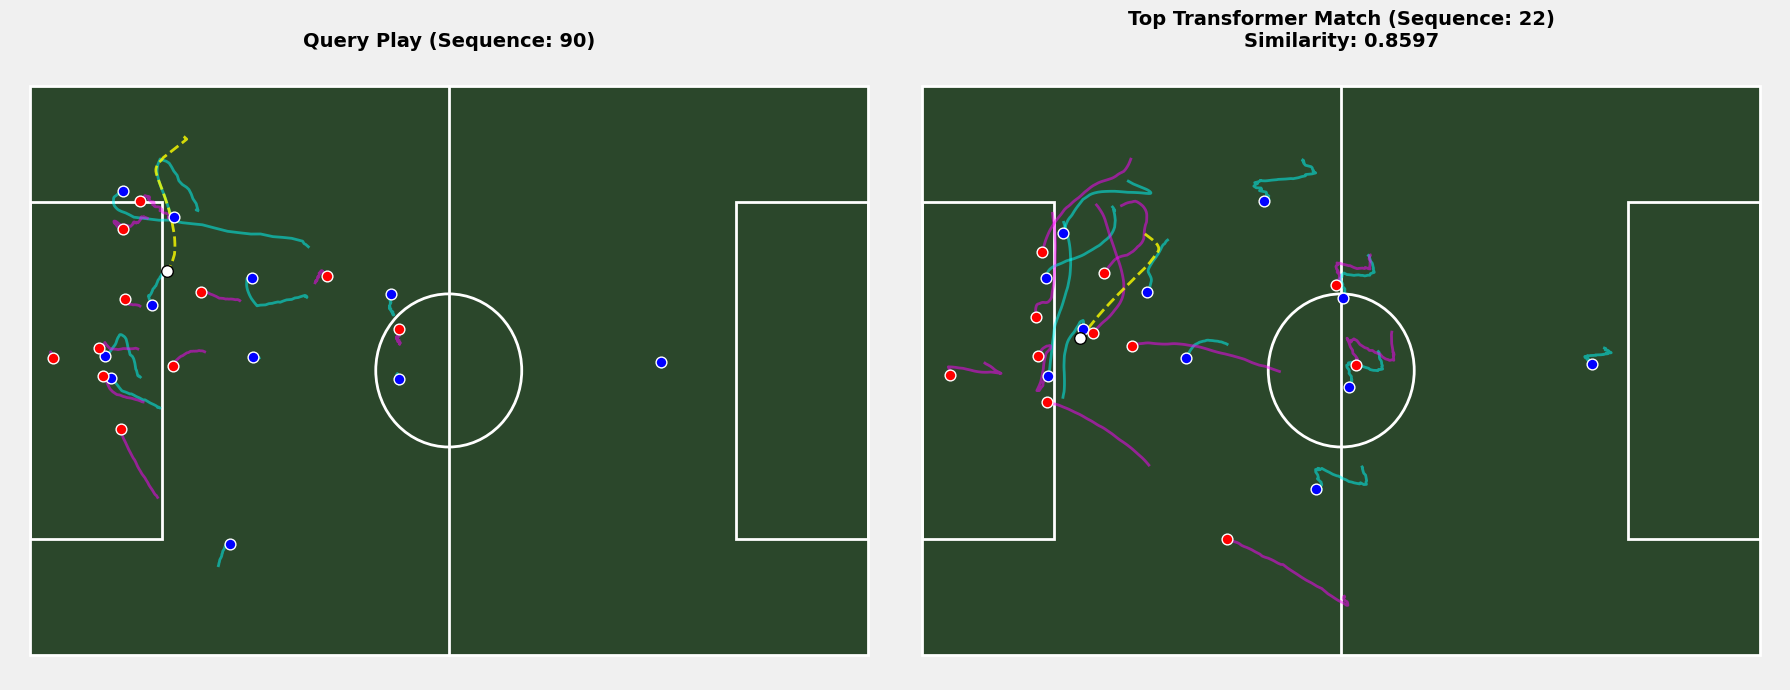

In [28]:
# Grab the raw coordinate tensors (Assuming query_idx and top_k_indices are from your search block)
query_coords_tensor = dataset[76]['coordinates']
match_coords_tensor = dataset[top_k_indices[1].item()]['coordinates'] # Index 1 is the Top Match

# Get the exact sequence IDs and the similarity score
query_seq_id = dataset[76]['sequence_id']
match_seq_id = dataset[top_k_indices[1].item()]['sequence_id']
score = top_k_scores[1].item()

# Run the plot
compare_plays_visually(query_coords_tensor, match_coords_tensor, query_seq_id, match_seq_id, score)